# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ville\AppData\Local\Temp\ipykernel_13288\1524811786.py:20: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$T$ ($\degree$C)')


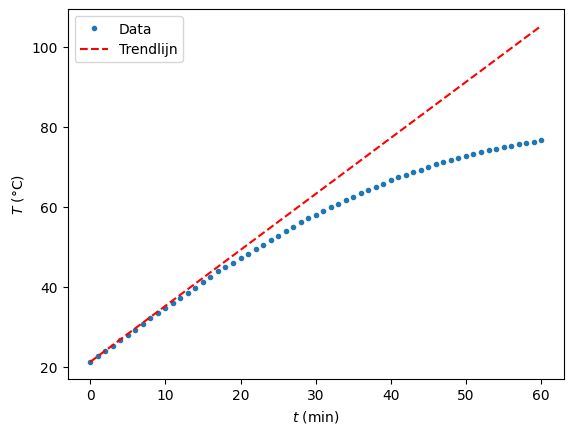

In [10]:
import numpy as np
import matplotlib.pyplot as plt
tempmeting=np.loadtxt('tempmetingen.csv', skiprows=1, delimiter=';')
tijd=tempmeting[:,0]
temp=tempmeting[:,1]
m_beker = 820.8/1000 #kg
m_start = 1292.9/1000 #kg
m_eind = 1274.9/1000 #kg

t_test=np.linspace(0,np.max(tijd),100)

# Het gemiddelde van de eerste 2 metingen geeft een goede benadering van de trendlijn. Hierbij wordt aangenomen dat er bij deze lage temperaturen nog geen verdamping optreedt.
def trendlijn(t):
    return ((temp[1]-temp[0])/(tijd[1]-tijd[0]))*t+temp[0]

# Plot maken
plt.plot(tijd, temp, '.', label='Data')
plt.plot(t_test, trendlijn(t_test), 'r--', label='Trendlijn')
plt.xlabel('$t$ (min)')
plt.ylabel('$T$ ($\degree$C)')
plt.legend()
plt.show()

In [ ]:
# Constantes: (Dit geldt alleen bij 1 atm)
c=4.186 #kJ/kgK soortelijke warmte water
L_v = 2256 # kJ/kg, verdampingswarmte water

m_water_start = m_start - m_beker
m_water_eind = m_eind - m_beker
m_verdamp = m_water_start - m_water_eind
delta_T = temp[-1] - temp[0] 

# De warmte die erin moet als er niks zou verdampen volgens de trendlijn.
# Hierbij wordt aangenomen dat de trendlijn goed gebruikt kan worden om de totale ingevoerde energie te bepalen.
Q_zonder_damp=c*(m_water_start)*(np.max(trendlijn(t_test))-np.min(trendlijn(t_test)))
print('De warmte die geleverd moet worden als er niks zou verdampen volgens de trendlijn is %.2f kJ' % Q_zonder_damp)


# Energieberekeningen volgens de theorie.
# Hierbij wordt aangenomen dat alle warmte die wordt toegevoerd gebruikt wordt voor het verwarmen en verdampen van het water.
Q_opwarming = m_water_eind * c * delta_T
Q_verdamping = m_verdamp * L_v
Q_totaal = Q_opwarming + Q_verdamping
print('De warmte die geleverd moet worden als er niks zou verdampen volgens de theorie is: %.2f kJ' %Q_totaal)

# Resultaat
print('Deze waarden komen niet overeen, de toegevoerde energie correspondeert dus niet met de opwarming en verdamping van het water.')

De warmte die geleverd moet worden als er niks zou verdampen volgens de trendlijn is 166.00 kJ
De warmte die geleverd moet worden als er niks zou verdampen volgens de theorie is: 145.92 kJ
Deze waarden komen niet overeen, de toegevoerde energie correspondeert dus niet met de opwarming en verdamping van het water.


In [15]:
print('Aanbevelingen voor verbetering van het experiment:')
print('1. Isoleer de buitenkant van de maatbeker om warmteverlies te minimaliseren. De bovenkant moet niet afgesloten worden, anders kan er geen verdamping plaatsvinden.')
print('2. Gebruik een roerstaaf voor een homogeen temperatuurverloop.')
print('3. Meet de elektrische spanning en stroom van het verwarmingselement voor betere energieberekening.')
print('4. Meet vaker (bijvoorbeeld elke 10 s) voor meer en betere data.')

Aanbevelingen voor verbetering van het experiment:
1. Isoleer de buitenkant van de maatbeker om warmteverlies te minimaliseren. De bovenkant moet niet afgesloten worden, anders kan er geen verdamping plaatsvinden.
2. Gebruik een roerstaaf voor een homogeen temperatuurverloop.
3. Meet de elektrische spanning en stroom van het verwarmingselement voor betere energieberekening.
4. Meet vaker (bijvoorbeeld elke 10 s) voor meer en betere data.
